# Deadtime estimates (JSON-derived)
This notebook consumes the aggregated estimates produced by `scripts/generate_deadtime_estimates.py` and plots them directly, avoiding repeated raw JSONL parsing.

In [1]:

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import sys

ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / 'src'))
from deadtime_analysis.plotting import set_log2_with_decade_ticks

EST_PATH = ROOT / 'data' / 'estimated_deadtime_10hz-12-22-25_full_channels.json'

with EST_PATH.open() as fh:
    estimates = json.load(fh)

df = pd.DataFrame(estimates)
# Useful typed columns
for col in ['channel_count', 'windows', 'num_pulses']:
    df[col] = df[col].astype('Int64')

df.head()


,pulse_rate_hz,channel_count,windows,num_pulses,channel_ratio_required,full_channels_required,tested_max_separation_ns,converged_deadtime_ns,converged_deadtime_us,converged_lower_bound_ns,converged_upper_bound_ns,converged_lower_bound_us,converged_upper_bound_us,min_all_pulses_response_ns,min_all_pulses_response_us,min_all_pulses_lower_bound_ns,min_all_pulses_lower_bound_us,all_pulses_observed,note
0,10.0,1,1,2,False,True,2500250.0,3894.0,3.894,3856.0,3932.0,3.856,3.932,3932.0,3.932,3894.0,3.894,True,None
1,10.0,1,2,2,False,True,2500250.0,7631.0,7.631,7593.0,7670.0,7.593,7.670,7670.0,7.670,7631.0,7.631,True,None
2,10.0,1,4,2,False,True,2500250.0,15107.0,15.107,15069.0,15146.0,15.069,15.146,15146.0,15.146,14993.0,14.993,True,None
3,10.0,1,8,2,False,True,2500250.0,29983.0,29.983,29945.0,30021.0,29.945,30.021,30021.0,30.021,29793.0,29.793,True,None
4,10.0,1,16,2,False,True,2500250.0,59735.0,59.735,59697.0,59773.0,59.697,59.773,59773.0,59.773,59087.0,59.087,True,None


## Min multi-pulse separation vs windows (JSON estimates)
Replicates `analysis.plot_min_double_vs_windows` but uses the precomputed JSON estimates instead of raw JSONL. Panels per pulse count, curves per pulser rate, x = windows (log2). Error bars use the lower bound only.

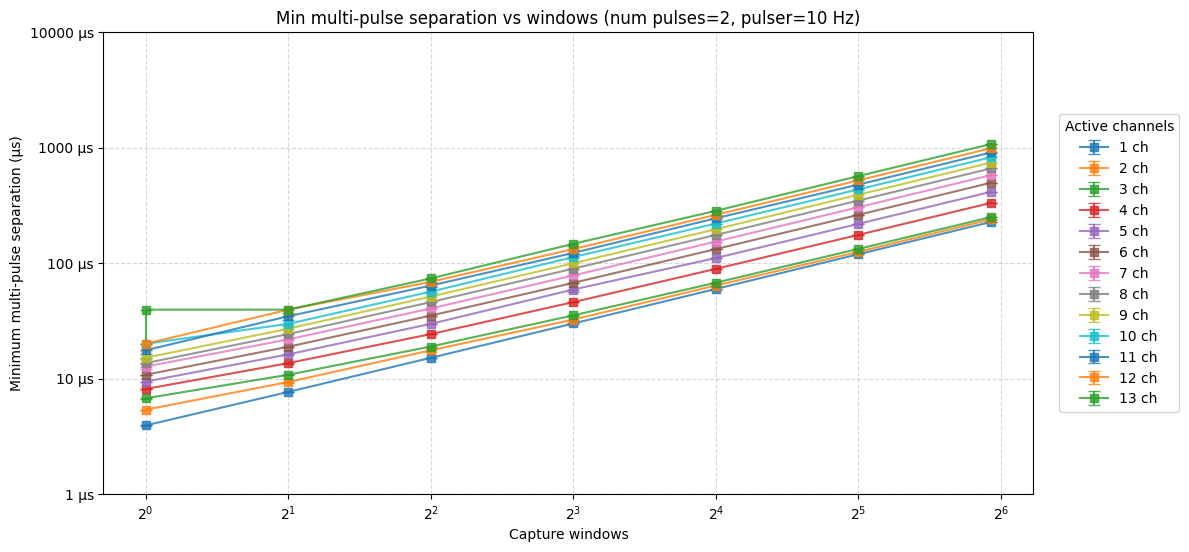

In [2]:

PULSE_RATES = sorted(df['pulse_rate_hz'].unique())
PULSE_COUNTS = sorted(df['num_pulses'].dropna().unique())

for rate in PULSE_RATES:
    for num_p in PULSE_COUNTS:
        sub = df[(df['num_pulses']==num_p) & (df['pulse_rate_hz']==rate)]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(12,6))
        for channel_count, ch_df in sub.groupby('channel_count'):
            ch_df = ch_df.sort_values('windows')
            y = ch_df['min_all_pulses_response_us']
            lower = ch_df['min_all_pulses_lower_bound_us']
            lower_err = (y - lower).clip(lower=0)
            yerr = [lower_err, 0*y]
            ax.errorbar(
                ch_df['windows'],
                y,
                yerr=yerr,
                marker='s', linestyle='-', label=f"{int(channel_count)} ch",
                capsize=4,
                alpha=0.8,
            )
        ax.set_xscale('log', base=2)
        set_log2_with_decade_ticks(ax, 'y', unit='µs')
        ax.set_xlabel('Capture windows')
        ax.set_ylabel('Minimum multi-pulse separation (µs)')
        ax.set_title(f'Min multi-pulse separation vs windows (num pulses={int(num_p)}, pulser={rate:.0f} Hz)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title='Active channels', loc='center left', bbox_to_anchor=(1.02, 0.5))
        plt.show()


## 100 Hz slices (min multi-pulse separation)
These views ignore 10 Hz data to keep the dimensionality at four (windows, channels, pulse count, min separation).

In [3]:

# Restrict to 100 Hz for compact views
est_df_100 = df[df['pulse_rate_hz'] == 100.0].copy()
est_df_100.head()


,pulse_rate_hz,channel_count,windows,num_pulses,channel_ratio_required,full_channels_required,tested_max_separation_ns,converged_deadtime_ns,converged_deadtime_us,converged_lower_bound_ns,converged_upper_bound_ns,converged_lower_bound_us,converged_upper_bound_us,min_all_pulses_response_ns,min_all_pulses_response_us,min_all_pulses_lower_bound_ns,min_all_pulses_lower_bound_us,all_pulses_observed,note


### Heatmap overview (100 Hz)
Color shows min multi-pulse separation (µs); one panel per pulse count.

In [4]:

import seaborn as sns
sns.set_context('talk')

for n in sorted(est_df_100['num_pulses'].dropna().unique()):
    sub = est_df_100[est_df_100['num_pulses'] == n]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index='channel_count', columns='windows', values='min_all_pulses_response_us')
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis')
    plt.title(f'Min multi-pulse separation (µs) @100 Hz, pulses={int(n)}')
    plt.xlabel('Windows')
    plt.ylabel('Channels')
    plt.show()


### Min separation vs pulse count (curves by windows, fixed channel)
One plot per channel; curves are capture windows; x = pulse count; y = min separation (µs).

In [5]:

channels = sorted(est_df_100['channel_count'].dropna().unique())
windows = sorted(est_df_100['windows'].dropna().unique())

for ch in channels:
    sub = est_df_100[est_df_100['channel_count'] == ch]
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(10,6))
    for win in windows:
        win_df = sub[sub['windows'] == win].dropna(subset=['num_pulses'])
        if win_df.empty:
            continue
        win_df = win_df.sort_values('num_pulses')
        y = win_df['min_all_pulses_response_us']
        lower = win_df['min_all_pulses_lower_bound_us']
        yerr = [ (y - lower).clip(lower=0), 0*y ]
        ax.errorbar(win_df['num_pulses'], y, yerr=yerr, marker='o', linestyle='-', label=f"{int(win)} windows", capsize=4)
    ax.set_xlabel('Number of pulses')
    ax.set_ylabel('Minimum multi-pulse separation (µs)')
    ax.set_title(f'Min separation vs pulse count @100 Hz (channels={int(ch)})')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Capture windows', loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.show()


### Min separation vs pulse count (curves by channels, fixed windows)
One plot per capture-window count; curves are channel counts; x = pulse count; y = min separation (µs).

In [6]:

for win in windows:
    sub = est_df_100[est_df_100['windows'] == win]
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(10,6))
    for ch in channels:
        ch_df = sub[sub['channel_count'] == ch].dropna(subset=['num_pulses'])
        if ch_df.empty:
            continue
        ch_df = ch_df.sort_values('num_pulses')
        y = ch_df['min_all_pulses_response_us']
        lower = ch_df['min_all_pulses_lower_bound_us']
        yerr = [ (y - lower).clip(lower=0), 0*y ]
        ax.errorbar(ch_df['num_pulses'], y, yerr=yerr, marker='o', linestyle='-', label=f"{int(ch)} channels", capsize=4)
    ax.set_xlabel('Number of pulses')
    ax.set_ylabel('Minimum multi-pulse separation (µs)')
    ax.set_title(f'Min separation vs pulse count @100 Hz (windows={int(win)})')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Active channels', loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.show()
